In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Generate synthetic EEG-like data
# Simulating 4 sleep stages: Wake, Light Sleep (N1/N2), Deep Sleep (N3), REM

def generate_sleep_eeg_data(n_samples=1000, n_features=10):
    """
    Generate synthetic EEG data that mimics different sleep stages
    """
    X = []
    y = []
    
    # Define characteristics for each sleep stage
    # (We're making this synthetic but based on real EEG patterns)
    sleep_stages = {
        0: {'name': 'Wake', 'mean': 10, 'std': 3},           # Higher frequency, lower amplitude
        1: {'name': 'Light Sleep', 'mean': 5, 'std': 2},     # Medium frequency
        2: {'name': 'Deep Sleep', 'mean': 2, 'std': 1},      # Low frequency, high amplitude
        3: {'name': 'REM', 'mean': 8, 'std': 2.5}            # Mixed frequency
    }
    
    # Generate data for each stage
    for stage, props in sleep_stages.items():
        # Create n_samples/4 samples per stage
        stage_samples = n_samples // 4
        
        # Generate random EEG-like features (e.g., power in different frequency bands)
        stage_data = np.random.normal(
            loc=props['mean'], 
            scale=props['std'], 
            size=(stage_samples, n_features)
        )
        
        X.append(stage_data)
        y.extend([stage] * stage_samples)
    
    X = np.vstack(X)
    y = np.array(y)
    
    return X, y, sleep_stages

# Generate the data
X, y, sleep_stages = generate_sleep_eeg_data(n_samples=1000, n_features=10)

print(f"Dataset shape: {X.shape}")
print(f"Number of samples: {len(X)}")
print(f"Number of features: {X.shape[1]}")
print(f"\nSleep stage distribution:")
for stage_id, count in enumerate(np.bincount(y)):
    print(f"  {sleep_stages[stage_id]['name']}: {count} samples")

Dataset shape: (1000, 10)
Number of samples: 1000
Number of features: 10

Sleep stage distribution:
  Wake: 250 samples
  Light Sleep: 250 samples
  Deep Sleep: 250 samples
  REM: 250 samples


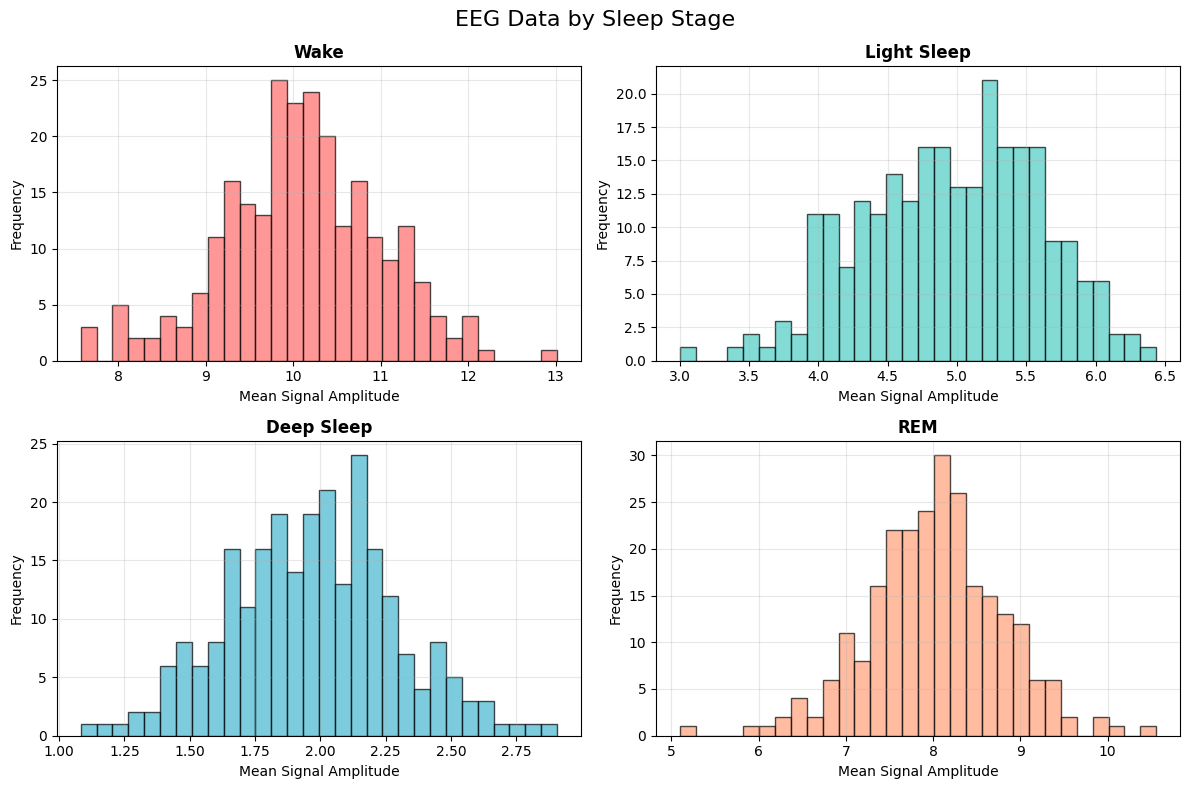

Data visualization complete!


In [5]:
# Visualize the data to understand what we're working with
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('EEG Data by Sleep Stage', fontsize=16)

stage_names = ['Wake', 'Light Sleep', 'Deep Sleep', 'REM']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for stage_id, (ax, name, color) in enumerate(zip(axes.flat, stage_names, colors)):
    # Get data for this stage
    stage_mask = y == stage_id
    stage_data = X[stage_mask]
    
    # Plot histogram of mean values
    ax.hist(stage_data.mean(axis=1), bins=30, color=color, alpha=0.7, edgecolor='black')
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean Signal Amplitude')
    ax.set_ylabel('Frequency')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Data visualization complete!")

In [6]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Normalize the data (important for ML models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData normalized!")

# Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

# Make predictions
y_pred = model.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2%}")

Training set size: 800
Test set size: 200

Data normalized!
Model trained successfully!

Model Accuracy: 93.50%


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Wake       0.91      0.84      0.88        50
 Light Sleep       0.98      1.00      0.99        50
  Deep Sleep       1.00      1.00      1.00        50
         REM       0.85      0.90      0.87        50

    accuracy                           0.94       200
   macro avg       0.94      0.93      0.93       200
weighted avg       0.94      0.94      0.93       200



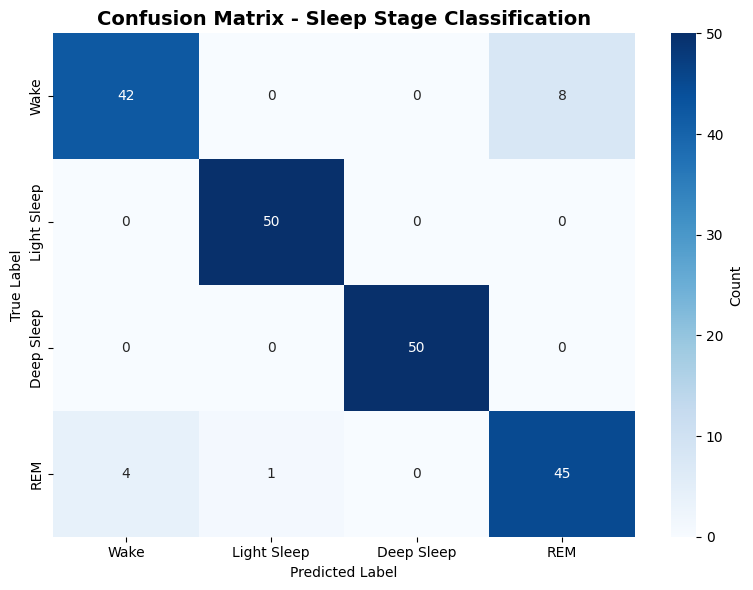


Confusion matrix visualization complete!


In [7]:
# Get detailed performance metrics
print("=" * 50)
print("DETAILED CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=stage_names))

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=stage_names, 
            yticklabels=stage_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Sleep Stage Classification', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\nConfusion matrix visualization complete!")